In [11]:
import pandas as pd
# 1. load the dataset
df = pd.read_csv('retail_sales.csv')

In [12]:
#display shape
df.shape

(80000, 17)

In [15]:
#display the datatype
print(df.dtypes)

order_id              str
customer_id           str
customer_name         str
customer_email        str
product_name          str
category              str
region                str
state                 str
quantity            int64
unit_price        float64
discount_rate     float64
net_revenue       float64
payment_method        str
order_date            str
delivery_days       int64
returned              str
salesperson_id        str
dtype: object


In [16]:
#Counting the missing values
print(df.isnull().sum())

order_id          0
customer_id       0
customer_name     0
customer_email    0
product_name      0
category          0
region            0
state             0
quantity          0
unit_price        0
discount_rate     0
net_revenue       0
payment_method    0
order_date        0
delivery_days     0
returned          0
salesperson_id    0
dtype: int64


In [17]:
#Count the duplicated rows
print(df.duplicated().sum())

0


In [18]:
#Extra order_date
import pandas as pd
# Convert to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])



In [19]:
# Extract components
df['year'] = df['order_date'].dt.year
df['quarter'] = 'Q' + df['order_date'].dt.quarter.astype(str)
df['month'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()



In [20]:

# Display counts
print(df['year'].value_counts().sort_index())
print(df['quarter'].value_counts().sort_index())
print(df['month'].value_counts())
print(df['day_of_week'].value_counts())



year
2021    26600
2022    26630
2023    26701
2024       69
Name: count, dtype: int64
quarter
Q1    19870
Q2    19902
Q3    20208
Q4    20020
Name: count, dtype: int64
month
January      6947
July         6889
March        6813
August       6782
October      6778
May          6732
December     6722
June         6592
April        6578
September    6537
November     6520
February     6110
Name: count, dtype: int64
day_of_week
Sunday       11501
Wednesday    11475
Saturday     11440
Friday       11417
Thursday     11392
Monday       11389
Tuesday      11386
Name: count, dtype: int64


In [24]:
 #1. Calculate the new gross_revenue column
df['gross_revenue'] = df['quantity'] * df['unit_price']


In [27]:
# Calculate expected net revenue after re-applying the discount rate
expected_net = df['gross_revenue'] * (1 - df['discount_rate'])

# Calculate the difference between the actual net revenue and the expected net revenue
difference = df['net_revenue'] - expected_net

In [28]:
# Verify if the difference is zero everywhere
print("Max formula variance:", difference.abs().max()) 


Max formula variance: 0.0


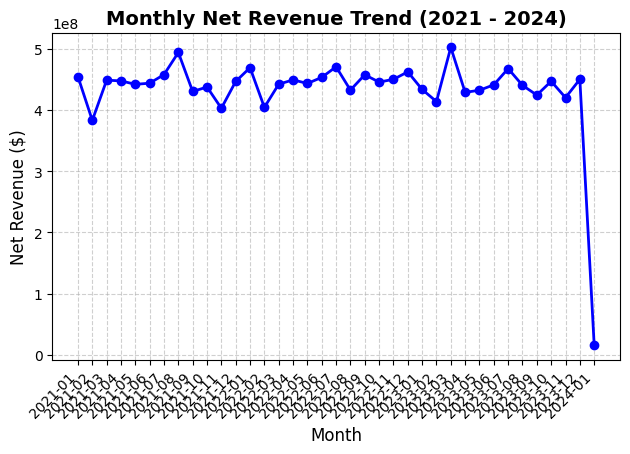

In [29]:
#import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract Year-Month periods
df['year_month'] = df['order_date'].dt.to_period('M')

# Aggregate net revenue by month
monthly_revenue = df.groupby('year_month')['net_revenue'].sum().reset_index()
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)

# Plot line chart
plt.plot(monthly_revenue['year_month_str'], monthly_revenue['net_revenue'], marker='o', color='b', linewidth=2)
plt.title('Monthly Net Revenue Trend (2021 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Net Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()





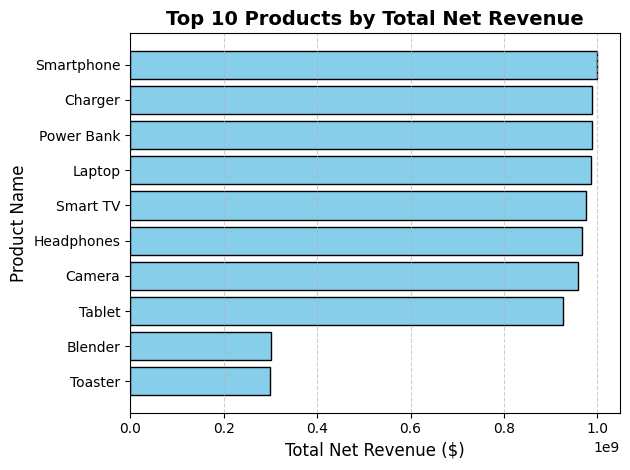

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')

# Group by product name and sum net revenue
product_revenue = df.groupby('product_name')['net_revenue'].sum().reset_index()

# Extract top 10 products
top_10_products = product_revenue.sort_values(by='net_revenue', ascending=False).head(10)

# Sort ascending for a horizontal bar chart so the highest revenue is at the top
top_10_sorted_hbar = top_10_products.sort_values(by='net_revenue', ascending=True)

# Plotting
plt.barh(top_10_sorted_hbar['product_name'], top_10_sorted_hbar['net_revenue'], color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Total Net Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Net Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()




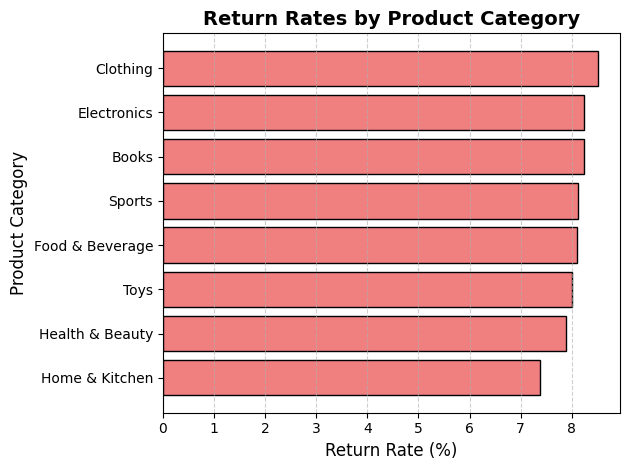

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')

# Convert the 'returned' text column into a binary numeric column (1 for Yes, 0 for No)
df['is_returned'] = df['returned'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Calculate the average return rate per category
category_returns = df.groupby('category')['is_returned'].mean().reset_index()
category_returns.columns = ['category', 'return_rate']

# Sort values in ascending order for a clean horizontal bar chart display
category_returns_sorted = category_returns.sort_values(by='return_rate', ascending=True)

# Generate the horizontal bar chart
plt.barh(category_returns_sorted['category'], category_returns_sorted['return_rate'] * 100, color='lightcoral', edgecolor='black')
plt.title('Return Rates by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Return Rate (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()




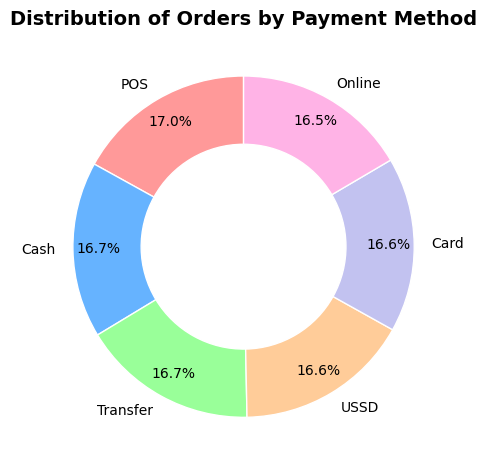

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')

# Calculate distribution of payment methods
payment_counts = df['payment_method'].value_counts()

# Set up labels, sizes, and colors
labels = payment_counts.index
sizes = payment_counts.values
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
# Create the donut chart (pie chart with a hollow center)
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors[:len(labels)], 
    pctdistance=0.85, 
    wedgeprops=dict(width=0.4, edgecolor='w') # width=0.4 creates the donut cutout
)

plt.title('Distribution of Orders by Payment Method', fontsize=14, fontweight='bold')
plt.tight_layout()



Correlation: 0.000855


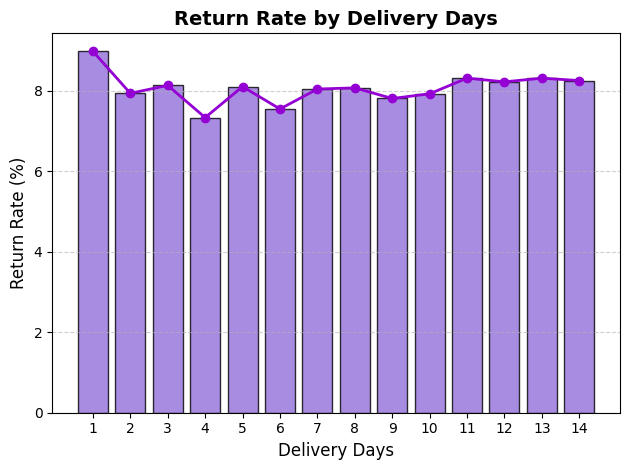

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')

# Convert 'returned' column to a binary numeric indicator (1 = Yes, 0 = No)
df['is_returned'] = df['returned'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Calculate the Pearson correlation coefficient 
correlation = df['delivery_days'].corr(df['is_returned'])
print(f"Correlation: {correlation:.6f}")

# Aggregate data by delivery days
delivery_stats = df.groupby('delivery_days')['is_returned'].mean().reset_index()
delivery_stats.columns = ['delivery_days', 'return_rate']

# Create the chart
plt.bar(delivery_stats['delivery_days'], delivery_stats['return_rate'] * 100, color='mediumpurple', edgecolor='black', alpha=0.8)
plt.plot(delivery_stats['delivery_days'], delivery_stats['return_rate'] * 100, color='darkviolet', marker='o', linewidth=2, label='Trendline')

plt.title('Return Rate by Delivery Days', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Days', fontsize=12)
plt.ylabel('Return Rate (%)', fontsize=12)
plt.xticks(delivery_stats['delivery_days'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()



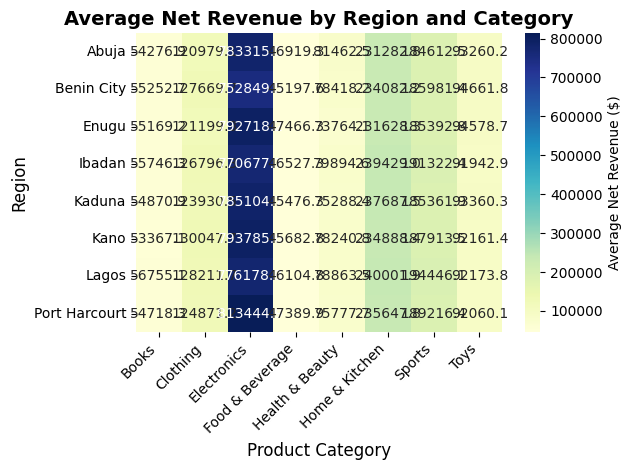

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('retail_sales.csv')

# Create a pivot table to aggregate average revenue by region and category
pivot_df = df.pivot_table(values='net_revenue', index='region', columns='category', aggfunc='mean')

# Generate the heatmap
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Average Net Revenue ($)'})
plt.title('Average Net Revenue by Region and Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


# Summary of findings
1.Electronics Dominate Revenue Performance
While order volume is evenly spread across categories, Electronics generates significantly more revenue per transaction than any other category. In all 8 regions analyzed, its average transaction value leads by a massive margin, peaking in Port Harcourt at an average of $813,444.88 per order. By contrast, categories like Food & Beverage and Books average under $60,000 per order.
2. High Consistency in Yearly & Monthly Revenue
Overall consumer demand has remained exceptionally stable over the years. Total order volumes hover consistently around 26,600 to 26,700 orders annually for 2021, 2022, and 2023. Monthly trends show that net revenue securely oscillates between $380M and $500M month-over-month with no extreme or volatile seasonal spikes.
3. Tech Accessories Claim the Top Individual Slots
When looking at individual items, tech products and accessories are the primary cash drivers. out of dozens of items in the store, Smartphones, Chargers, Power Banks, and Laptops claim the top four spots for highest total net revenue, with each of these single product lines pulling in between $986M and $998M in overall sales.
4. Clothing Bears the Highest Return Burden
An analysis of fulfillment flags indicates that Clothing has the highest return rate at 8.52%, followed closely by Electronics at 8.24%. Conversely, Home & Kitchen items are kept the most reliably by customers, yielding the dataset's lowest return rate at 7.38%.
5. Delivery Speeds Have Zero Impact on Customer Satisfaction
The statistical correlation between fulfillment duration (delivery_days) and customer return status (returned) sits at an extremely negligible 0.000855. This confirms that whether an order takes 1 day or a full 2 weeks to arrive at a customer's doorstep, it has practically zero influence on their likelihood to return the product.
